<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [199]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

##Import Dataset

In [200]:
url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

X = df.drop(['Female:Male ratio', 'rank_prefix', 'Industry'], axis=1)
y = df['Industry']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Drop NaNs if any were created in the target variable
train_data = train_data.dropna(subset=['Industry'])
test_data = test_data.dropna(subset=['Industry'])

##Define Functions for Model Evaluations

In [201]:
def VIF(df, columns):
    values = sm.add_constant(df[columns]).values
    num_columns = len(columns)+1
    vif = [variance_inflation_factor(values, i) for i in range(num_columns)]
    return pd.Series(vif[1:], index=columns)

In [202]:
# compute out-of-sample R-squared using the test set
def OSR(model, df_train, df_test, dependent_var):
    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

In [203]:
# compute out-of-sample R-squared using the test set
def OSR_alt(model, df_train, df_test, category_var, dependent_var, features):

    # Use drop_first=False to generate all dummies, then align to model columns
    # This prevents dropping a category that might be the reference in the test
    # set but not the train set
    df_test_encoded = pd.get_dummies(
        df_test[features],
        columns=[category_var],
        drop_first=False,
        dtype=float
    )

    df_test_encoded = sm.add_constant(df_test_encoded)

    # Align columns with the training data features (model parameters)
    # This adds missing columns (filled with 0) and removes extra ones
    df_test_encoded = df_test_encoded.reindex(columns=model.params.index,
                                              fill_value=0)

    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test_encoded)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

##Linear Regression

####Without "Name" column

In [204]:
ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model1 = ols.fit()
print(model1.summary())

OSR(model1, train_data, test_data, 'Industry')

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     3051.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:31:35   Log-Likelihood:                -5306.8
No. Observations:                1696   AIC:                         1.063e+04
Df Residuals:                    1686   BIC:                         1.069e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

np.float64(0.9437234867783865)

####With "Name" column

*Use one-hot encoding*

In [205]:
features = ['Name', 'Rank', 'No. of FTE students', 'No. of students per staff',
            'International students','Overall', 'Teaching',
            'Research Environment', 'Research Quality', 'International Outlook']
category_var = 'Name'

train_data_encode = pd.get_dummies(
    train_data[features],
    columns=[category_var],
    drop_first=True,
    dtype=float
)

train_data_encode = sm.add_constant(train_data_encode)

depend = train_data['Industry']
model_encode = sm.OLS(depend, train_data_encode).fit()
print(model_encode.summary())

OSR_alt(model_encode, train_data, test_data, category_var, 'Industry', features)

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     164.5
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:31:36   Log-Likelihood:                -4798.6
No. Observations:                1696   AIC:                         1.013e+04
Df Residuals:                    1430   BIC:                         1.158e+04
Df Model:                         265                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

np.float64(0.9627729762393783)

**Summary**

Remove the "Name" column as there would be ~200 one-hot encoded variables added to the linear regression, making the model more likely to overfit.

##Feature Selection

In [206]:
X_train = X_train.drop('Name', axis=1)
X_test = X_test.drop('Name', axis=1)
features.remove('Name')
VIF(train_data, features)

,0
Rank,6.597041
No. of FTE students,1.189986
No. of students per staff,1.348391
International students,2.866540
Overall,276.300880
Teaching,64.725479
Research Environment,76.860936
Research Quality,25.726009
International Outlook,8.023248


In [207]:
# Remove 'Overall' because of its high VIF
ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model2 = ols.fit()
print(model2.summary())

OSR(model2, train_data, test_data, 'Industry')

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     44.83
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.34e-65
Time:                        00:31:36   Log-Likelihood:                -7560.1
No. Observations:                1696   AIC:                         1.514e+04
Df Residuals:                    1687   BIC:                         1.519e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

np.float64(0.1290237415251304)

**Note**

Because the R-squared value dropped significantly, we shouldn't remove the feature 'Overall'

In [208]:
# Remove 'Research Environment', the second highest VIF

ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Teaching + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model1 = ols.fit()
print(model1.summary())

OSR(model1, train_data, test_data, 'Industry')

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     104.4
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.80e-141
Time:                        00:31:36   Log-Likelihood:                -7382.6
No. Observations:                1696   AIC:                         1.478e+04
Df Residuals:                    1687   BIC:                         1.483e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

np.float64(0.2922278044179748)

**Note**

This R-squared value is still significantly smaller than model1, despite it having the second highest VIF value.

Thus, we must use PCA to combine features that are highly correlated with each. In this case, they are most likely 'Overall', 'Research Environment', and (possibly) 'Teaching'.

##PCA

In [209]:
# (Similar to lab 8)

# Candidate numbers of principal components (max is the number of features in X_train)
max_components = X_train.shape[1]
component_grid = list(range(1, max_components + 1))

# K-fold CV object (Use KFold instead of StratifiedKFold for continuous targets)
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV accuracy (R-squared) for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, fold R^2 = {[round(x, 4) for x in fold_R_sq]}, mean = {cv_scores[k]:.4f}")


k =  1, fold R^2 = [-0.0068, 0.001, -0.0127, -0.0093, -0.0025], mean = -0.0061
k =  2, fold R^2 = [0.0171, -0.0057, 0.017, 0.0096, 0.0501], mean = 0.0176
k =  3, fold R^2 = [0.0174, -0.0029, 0.0246, 0.0288, 0.0564], mean = 0.0248
k =  4, fold R^2 = [0.056, 0.0632, 0.0689, 0.058, 0.1279], mean = 0.0748
k =  5, fold R^2 = [0.1354, 0.1395, 0.1284, 0.1204, 0.216], mean = 0.1480
k =  6, fold R^2 = [0.1455, 0.1442, 0.1407, 0.1468, 0.2389], mean = 0.1632
k =  7, fold R^2 = [0.1737, 0.1552, 0.1521, 0.1778, 0.227], mean = 0.1771
k =  8, fold R^2 = [0.176, 0.1595, 0.149, 0.1813, 0.2311], mean = 0.1794
k =  9, fold R^2 = [0.4597, 0.4262, 0.4389, 0.372, 0.4184], mean = 0.4231
k = 10, fold R^2 = [0.9407, 0.9475, 0.9422, 0.9435, 0.9447], mean = 0.9437


In [210]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV accuracy:", cv_scores[best_k])


Best number of principal components: 10
Best mean CV accuracy: 0.9437086798866684


In [211]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train)
X_test_pca_best = pca_best.transform(X_test)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_acc = lr_best.score(X_train_pca_best, y_train)
test_acc = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train accuracy:", round(train_acc, 4))
print("Test accuracy :", round(test_acc, 4))


Final model results
Train accuracy: 0.9449
Test accuracy : 0.9464


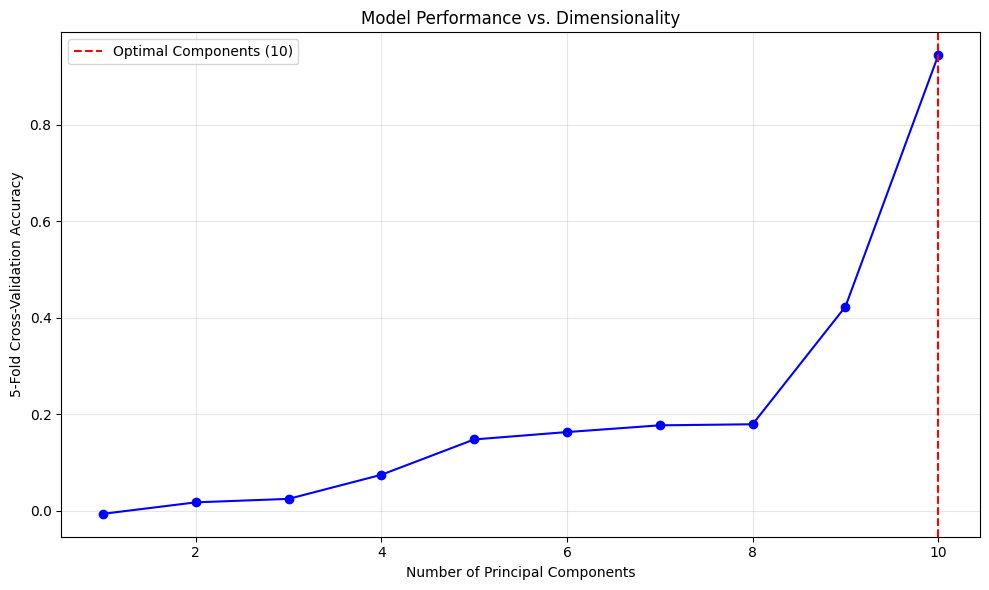

In [212]:
# --- VISUALIZATION: Cross-Validation Accuracy Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation Accuracy')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()